### HyTAC Evaluation & Visualization


Times: [ 0.    0.33  1.    4.   24.  ]
Err no-assim: [1.10934074e-04 1.32070705e-01 1.42503353e-02 2.21717823e-02
 1.31352806e+00]
Err with-assim: [1.10934074e-04 8.40989947e-02 8.60093813e-03 1.34150861e-02
 1.31352961e+00]


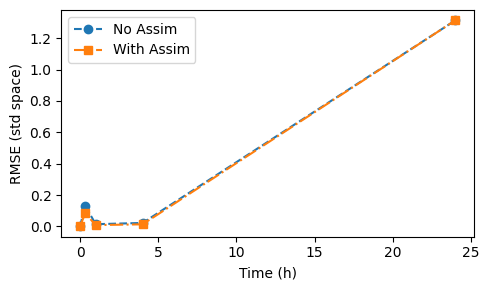

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import warnings 
warnings.filterwarnings('ignore')

ckpt_dir = "../checkpoints"
fig_dir = "../figures"
cfg_path = "../configs/default.json"

with open(cfg_path, "r") as f:
    cfg = json.load(f)

times = np.load(os.path.join(ckpt_dir, "times.npy"))
Z = np.load(os.path.join(ckpt_dir, "Z.npy"))
X_true = np.load("../" + cfg["data"]["atac_path"]).astype(np.float32)
X_true = np.log1p(np.maximum(X_true, 0.0))

import pickle
with open(os.path.join(ckpt_dir, "scaler.pkl"), "rb") as f:
    scaler = pickle.load(f)
with open(os.path.join(ckpt_dir, "pca.pkl"), "rb") as f:
    pca = pickle.load(f)

X_true_std = scaler.transform(X_true)

# Load predictions saved by predict.py
X_pred_std_noass = np.load(os.path.join(fig_dir, "X_pred_std_noass.npy"))
X_pred_std_assim = np.load(os.path.join(fig_dir, "X_pred_std_assim.npy"))

def rmse_timewise(a, b):
    return np.sqrt(((a - b) ** 2).mean(axis=1))

err_no = rmse_timewise(X_true_std, X_pred_std_noass)
err_as = rmse_timewise(X_true_std, X_pred_std_assim)

print("Times:", times)
print("Err no-assim:", err_no)
print("Err with-assim:", err_as)

# Plot RMSE vs time
os.makedirs(fig_dir, exist_ok=True)
plt.figure(figsize=(5,3))
plt.plot(times, err_no, 'o--', label='No Assim')
plt.plot(times, err_as, 's-.', label='With Assim')
plt.xlabel('Time (h)')
plt.ylabel('RMSE (std space)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "nb_rmse_vs_time.png"), dpi=300)
plt.show()


time(h)  no-assim   with-assim   delta
  0.00    0.0001       0.0001   +0.0000
  0.33    0.1321       0.0841   +0.0480
  1.00    0.0143       0.0086   +0.0056
  4.00    0.0222       0.0134   +0.0088
 24.00    1.3135       1.3135   -0.0000


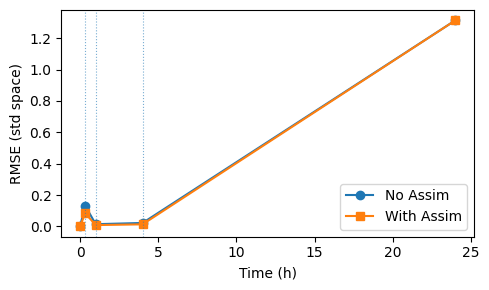

<Figure size 640x480 with 0 Axes>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

err_no = np.sqrt(((X_true_std - X_pred_std_noass)**2).mean(axis=1))
err_as = np.sqrt(((X_true_std - X_pred_std_assim)**2).mean(axis=1))

print("time(h)  no-assim   with-assim   delta")
for tt, a, b in zip(times, err_no, err_as):
    print(f"{tt:6.2f}  {a:8.4f}   {b:10.4f}   {a-b:+.4f}")

plt.figure(figsize=(5,3))
plt.plot(times, err_no, 'o-', label='No Assim')
plt.plot(times, err_as, 's-', label='With Assim')
for ta in [0.33, 1.0, 4.0]:
    # vertical markers at assim times
    plt.axvline(x=ta, ls=':', lw=0.8, alpha=0.6)
plt.xlabel('Time (h)'); plt.ylabel('RMSE (std space)')
plt.legend(); plt.tight_layout(); plt.show()
plt.savefig(os.path.join(fig_dir, "nb_rmse_vs_time2.png"), dpi=300)

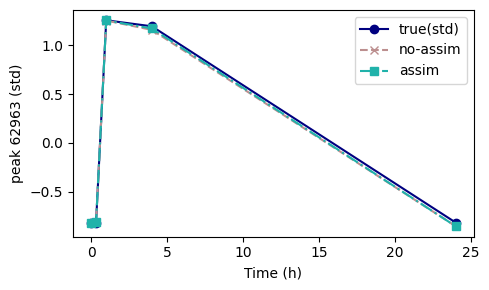

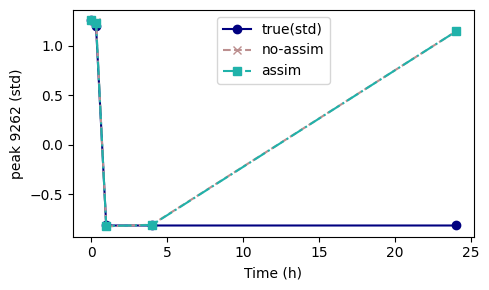

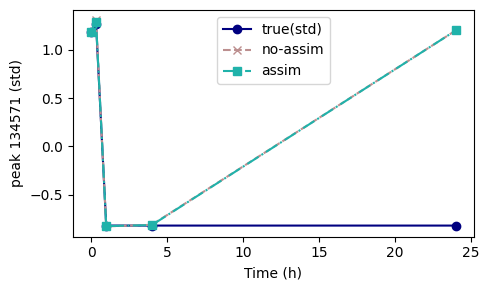

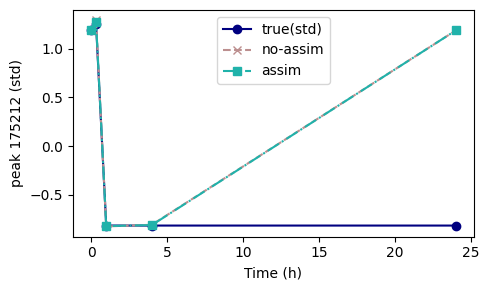

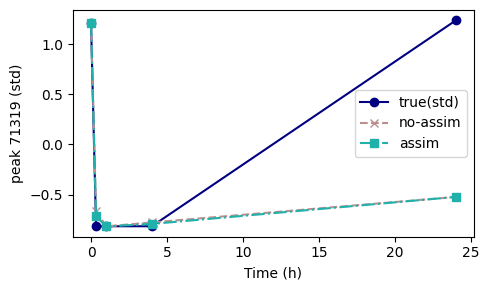

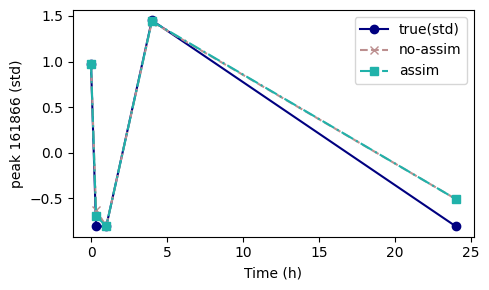

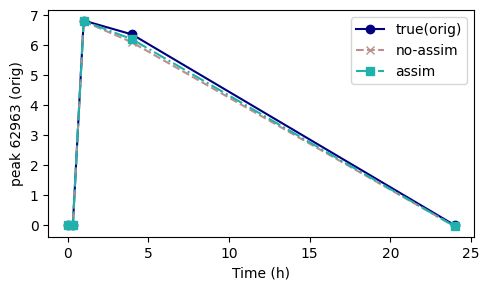

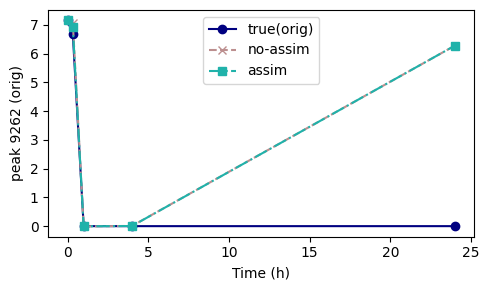

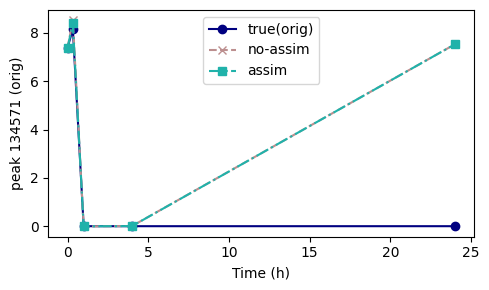

In [5]:
# Plot top-variance peaks (std space) and original space
var = X_true_std.var(axis=0)
idx = np.argsort(var)[-6:][::-1]

colors = ['#000080','#BC8F8F','#20B2AA']

for k, p in enumerate(idx):
    plt.figure(figsize=(5,3))
    plt.plot(times, X_true_std[:, p], marker='o', color=colors[0], label='true(std)')
    plt.plot(times, X_pred_std_noass[:, p], marker='x', linestyle='--', color=colors[1], label='no-assim')
    plt.plot(times, X_pred_std_assim[:, p], marker='s', linestyle='-.', color=colors[2], label='assim')
    plt.xlabel('Time (h)')
    plt.ylabel(f'peak {p} (std)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"nb_peak_std_{k}_{p}.png"), dpi=300)
    plt.show()

# original scale
X_true_orig = np.expm1(scaler.inverse_transform(X_true_std))
X_no_orig = np.expm1(scaler.inverse_transform(X_pred_std_noass))
X_as_orig = np.expm1(scaler.inverse_transform(X_pred_std_assim))

for k, p in enumerate(idx[:3]):
    plt.figure(figsize=(5,3))
    plt.plot(times, X_true_orig[:, p], marker='o', color=colors[0], label='true(orig)')
    plt.plot(times, X_no_orig[:, p], marker='x', color=colors[1], linestyle='--', label='no-assim')
    plt.plot(times, X_as_orig[:, p], marker='s', color=colors[2], linestyle='-.', label='assim')
    plt.xlabel('Time (h)')
    plt.ylabel(f'peak {p} (orig)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"nb_peak_orig_{k}_{p}.png"), dpi=300)
    plt.show()

  File "d:\ProgramData\anaconda3\envs\dytac\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "d:\ProgramData\anaconda3\envs\dytac\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\ProgramData\anaconda3\envs\dytac\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\ProgramData\anaconda3\envs\dytac\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


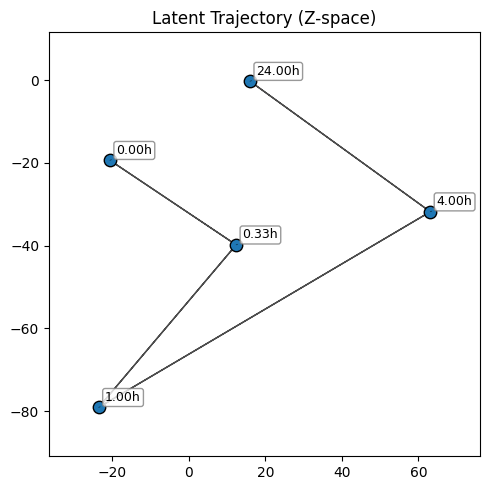

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

perp = min(3, len(Z)-1) if len(Z) > 1 else 1
emb = TSNE(n_components=2, perplexity=perp, learning_rate=50, init='pca', random_state=0).fit_transform(Z)

x, y = emb[:,0], emb[:,1]

mx, my = (x.max()-x.min())*0.15, (y.max()-y.min())*0.15
xmin, xmax = x.min()-mx, x.max()+mx
ymin, ymax = y.min()-my, y.max()+my

plt.figure(figsize=(5,5))
plt.scatter(x, y, s=80, zorder=2, edgecolors='k')

for i in range(len(Z)-1):
    dx, dy = x[i+1]-x[i], y[i+1]-y[i]
    plt.arrow(x[i], y[i], dx, dy, length_includes_head=True, head_width=0.02*max(mx,my),
              head_length=0.03*max(mx,my), alpha=0.7, zorder=1)

for i, tt in enumerate(times):
    offx = 0.015*(xmax-xmin)
    offy = 0.015*(ymax-ymin)
    px = np.clip(x[i]+offx, xmin, xmax)
    py = np.clip(y[i]+offy, ymin, ymax)
    plt.annotate(f"{tt:.2f}h",
                 xy=(x[i], y[i]), xytext=(px, py),
                 arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.6),
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8),
                 fontsize=9)

plt.xlim(xmin, xmax); plt.ylim(ymin, ymax)
plt.title("Latent Trajectory (Z-space)")
plt.tight_layout()
plt.show()